In [2]:
%reload_ext autoreload
%autoreload 2

import sys
import os

# Go up two directories from /notebooks/misc/ to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)


from pathlib import Path
import numpy as np
import pandas as pd
from aldiscore.prediction import utils
from aldiscore import ROOT, RSTATE

from aldiscore.prediction.predictor import DifficultyPredictor




In [ ]:
# data_dir = Path("/data/lucia/alignment-project/paper")
# feat_df, drop_df, labels = utils.load_features(
#     data_dir,
#     exclude_features=["is_dna", "num_seqs", "seq_length", "10-mer_js", "13-mer_js"],
# )
# # feat_df.columns = clean_feat_names

# print(feat_df.shape)
# print(drop_df.shape)
# print(labels.shape)



In [3]:
# read parquet files from auxiliary directory
feat_path = "/hits/fast/cme/luciamf/msa_difficulty/alignment-project/auxiliary/feat_df.parquet"
drop_path = "/hits/fast/cme/luciamf/msa_difficulty/alignment-project/auxiliary/drop_df.parquet"
labels_path = "/hits/fast/cme/luciamf/msa_difficulty/alignment-project/auxiliary/label_df.parquet"


performance_path = "/hits/fast/cme/luciamf/msa_difficulty/alignment-project/aldiscore/logs/reporting_lucia/report_842326.parquet"



feat_df = pd.read_parquet("/hits/fast/cme/luciamf/msa_difficulty/alignment-project/auxiliary/feat_df.parquet", engine="fastparquet")
drop_df = pd.read_parquet("/hits/fast/cme/luciamf/msa_difficulty/alignment-project/auxiliary/drop_df.parquet", engine="fastparquet")
labels = pd.read_parquet("/hits/fast/cme/luciamf/msa_difficulty/alignment-project/auxiliary/label_df.parquet", engine="fastparquet")
perf_df = pd.read_parquet(performance_path, engine="fastparquet")


In [11]:
feat_list = list(feat_df.columns)
unique_names = sorted({
    c.split('.', 1)[1] for c in feat_list if '.' in c
})

print(unique_names)

['10-mer_ent', '13-mer_ent', '4-mer_ent', '4-mer_js', '7-mer_ent', '7-mer_js', 'char_ent', 'char_js', 'hpoly_js_count', 'hpoly_js_len', 'psa_gap_len_mean', 'psa_gap_len_std', 'psa_gap_ratio', 'psa_score_ratio', 'psa_stretch_ratio', 'psa_tc_max', 'psa_tc_mean', 'psa_tc_min', 'psa_tc_p50', 'psa_tc_std']


In [12]:
print(feat_list)

['lbgp', 'min.char_ent', 'max.char_ent', 'mean.char_ent', 'std.char_ent', 'p1.char_ent', 'p5.char_ent', 'p10.char_ent', 'p20.char_ent', 'p30.char_ent', 'p40.char_ent', 'p50.char_ent', 'p60.char_ent', 'p70.char_ent', 'p80.char_ent', 'p90.char_ent', 'p95.char_ent', 'p99.char_ent', 'iqr.char_ent', 'min.char_js', 'max.char_js', 'mean.char_js', 'std.char_js', 'p1.char_js', 'p5.char_js', 'p10.char_js', 'p20.char_js', 'p30.char_js', 'p40.char_js', 'p50.char_js', 'p60.char_js', 'p70.char_js', 'p80.char_js', 'p90.char_js', 'p95.char_js', 'p99.char_js', 'iqr.char_js', 'min.hpoly_js_count', 'max.hpoly_js_count', 'mean.hpoly_js_count', 'std.hpoly_js_count', 'p1.hpoly_js_count', 'p5.hpoly_js_count', 'p10.hpoly_js_count', 'p20.hpoly_js_count', 'p30.hpoly_js_count', 'p40.hpoly_js_count', 'p50.hpoly_js_count', 'p60.hpoly_js_count', 'p70.hpoly_js_count', 'p80.hpoly_js_count', 'p90.hpoly_js_count', 'p95.hpoly_js_count', 'p99.hpoly_js_count', 'iqr.hpoly_js_count', 'min.hpoly_js_len', 'max.hpoly_js_len', 

In [ ]:
perf_df["R^2"] = pd.to_numeric(perf_df["R^2"], errors="coerce")
r2_median = perf_df["R^2"].median()
r2_p10 = np.percentile(perf_df["R^2"], 10)
r2_p90 = np.percentile(perf_df["R^2"], 90)

print(f"R² median = {r2_median:.3f} (10th–90th percentile: {r2_p10:.3f}–{r2_p90:.3f})")

R² median = 0.945 (10th–90th percentile: 0.939–0.951)


In [ ]:
print(drop_df.describe())



           num_seqs  min.seq_length  max.seq_length  mean.seq_length  \
count  11431.000000    11431.000000    11431.000000     11431.000000   
mean      30.777097      411.220103      704.500744       609.857636   
std       36.338216      741.752226     1206.662391      1052.807616   
min        3.000000        5.000000       23.000000        22.918919   
25%        5.000000       81.000000       99.000000        88.357143   
50%       12.000000      148.000000      230.000000       194.600000   
75%       50.000000      418.000000      599.500000       520.938017   
max      233.000000     7743.000000     7954.000000      7840.723404   

       std.seq_length  p1.seq_length  p5.seq_length  p10.seq_length  \
count    11431.000000   11431.000000   11431.000000    11431.000000   
mean        77.115424     434.779632     483.587595      515.368131   
std        203.369020     776.571776     857.415056      910.701775   
min          0.000000      16.840000      21.000000       21.000000

In [ ]:
drop_df.head()

is_dna  num_seqs  min.seq_length  max.seq_length  \
source    dataset                                                     
arthropod CYP_12    False       141             477             558   
          CYP_15    False       148             466             524   
          CYP_18    False       124             417             569   
          CYP_2     False        16             490             544   
          CYP_20    False        19             462             494   

                   mean.seq_length  std.seq_length  p1.seq_length  \
source    dataset                                                   
arthropod CYP_12        527.304965       13.154803         495.00   
          CYP_15        491.344595        7.691442         470.29   
          CYP_18        528.685484       16.380243         471.90   
          CYP_2         497.187500       12.890009         490.00   
          CYP_20        472.578947        7.995497         462.00   

                   p5.seq_length  p10.seq_length  p20.seq_length  ...  \
source    dataset                                                 ...   
arthropod CYP_12           501.0           514.0           518.0  ...   
          CYP_15           483.0           485.0           486.0  ...   
          CYP_18           509.0           513.6           520.6  ...   
          CYP_2            490.0           490.0           490.0  ...   
          CYP_20           462.0           462.0           467.0  ...   

                   p40.seq_length  p50.seq_length  p60.seq_length  \
source    dataset                                                   
arthropod CYP_12            525.0           527.0           532.0   
          CYP_15            488.0           490.5           493.0   
          CYP_18            528.0           530.0           533.0   
          CYP_2             491.0           493.5           494.0   
          CYP_20            469.2           471.0           473.0   

                   p70.seq_length  p80.seq_length  p90.seq_length  \
source    dataset                                                   
arthropod CYP_12            534.0           537.0           541.0   
          CYP_15            494.0           496.0           499.0   
          CYP_18            537.0           538.0           541.0   
          CYP_2             495.5           501.0           503.0   
          CYP_20            475.4           477.0           482.0   

                   p95.seq_length  p99.seq_length  iqr.seq_length  \
source    dataset                                                   
arthropod CYP_12            549.0          556.60            19.0   
          CYP_15            504.0          516.18            10.0   
          CYP_18            544.0          562.62            17.4   
          CYP_2             514.0          538.00            11.0   
          CYP_20            486.8          492.56            10.0   

                   seq_length_ratio  
source    dataset                    
arthropod CYP_12           0.854839  
          CYP_15           0.889313  
          CYP_18           0.732865  
          CYP_2            0.900735  
          CYP_20           0.935223  

[5 rows x 21 columns]

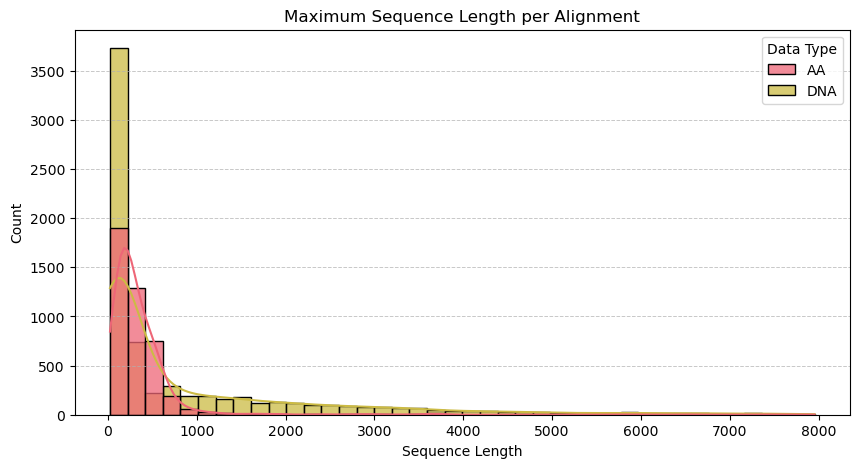

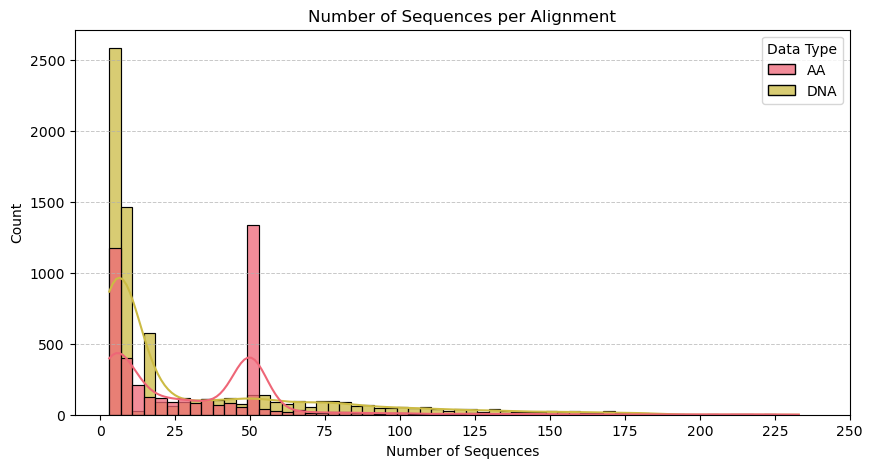

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map boolean to string labels
drop_df['Data Type'] = drop_df['is_dna'].map({True: 'DNA', False: 'AA'})

# Set a nice color palette
# palette = {'DNA': "skyblue", 'AA': "salmon"}

tol_bright = {
    "blue":   "#4477AA",
    "red":    "#EE6677",
    "green":  "#228833",
    "yellow": "#CCBB44",
    "cyan":   "#66CCEE",
    "purple": "#AA3377",
    "grey":   "#BBBBBB",
}

palette = {
    'DNA': "#CCBB44",  # blue
    'AA': "#EE6677"}   # orange

# 1. Distribution of Mean Sequence Lengths
plt.figure(figsize=(10, 5))
sns.histplot(data=drop_df, x='max.seq_length', hue='Data Type', bins=40, kde=True, palette=palette, alpha=0.75)
plt.title('Maximum Sequence Length per Alignment')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

plt.show()



# 2. Distribution of Number of Sequences
plt.figure(figsize=(10, 5))
sns.histplot(data=drop_df, x='num_seqs', hue='Data Type', bins=60, kde=True, palette=palette, alpha=0.75)
plt.title('Number of Sequences per Alignment')
plt.xlabel('Number of Sequences')
plt.ylabel('Count')
max_x = drop_df['num_seqs'].max()
plt.xticks(np.arange(0, max_x + 25, 25))
plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

plt.show()





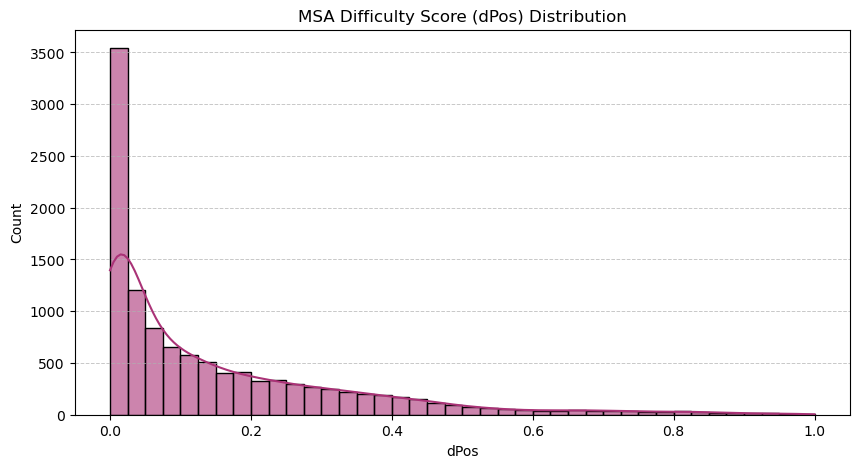

In [ ]:
# 1. Distribution of Mean Sequence Lengths

# maybe split by dna and aa here too
plt.figure(figsize=(10, 5))
sns.histplot(data=labels, x='dpos', bins=40, color = "#AA3377", kde=True, alpha=0.6) # change this to a pareto distribution, scipy.stats.pareto
plt.title('MSA Difficulty Score (dPos) Distribution')
plt.xlabel('dPos')
plt.ylabel('Count')
plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

plt.show()

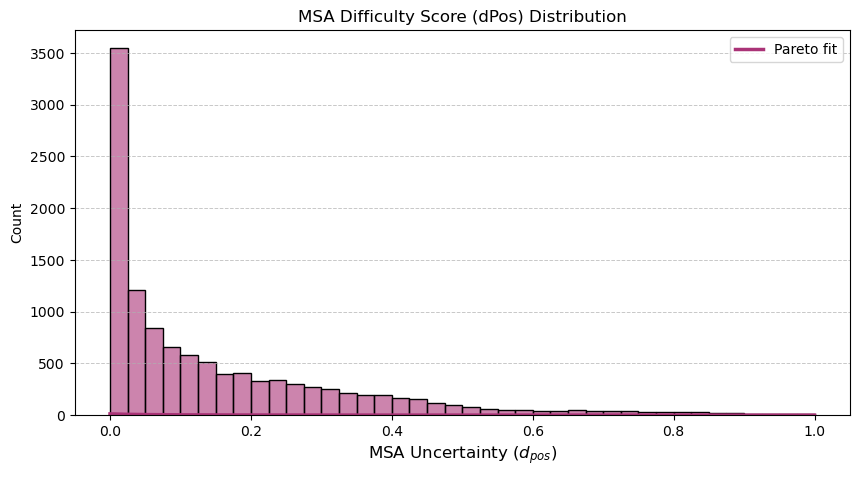

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pareto

# Data
data = labels['dpos']

# Fit Pareto shape parameter (optional but recommended)
shape, loc, scale = pareto.fit(data)

# Create x values over the data range
x = np.linspace(data.min(), data.max(), 500)

# Pareto PDF
pareto_pdf = pareto.pdf(x, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 5))

# Histogram
sns.histplot(data=data, bins=40, color="#AA3377", alpha=0.6)

# Pareto distribution curve
plt.plot(x, pareto_pdf, linewidth=2.5, color="#AA3377", label="Pareto fit")

plt.title('MSA Difficulty Score (dPos) Distribution')
plt.xlabel(r"MSA Uncertainty ($d_{pos}$)", size=12)
plt.ylabel('Count')
plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.legend()

plt.show()

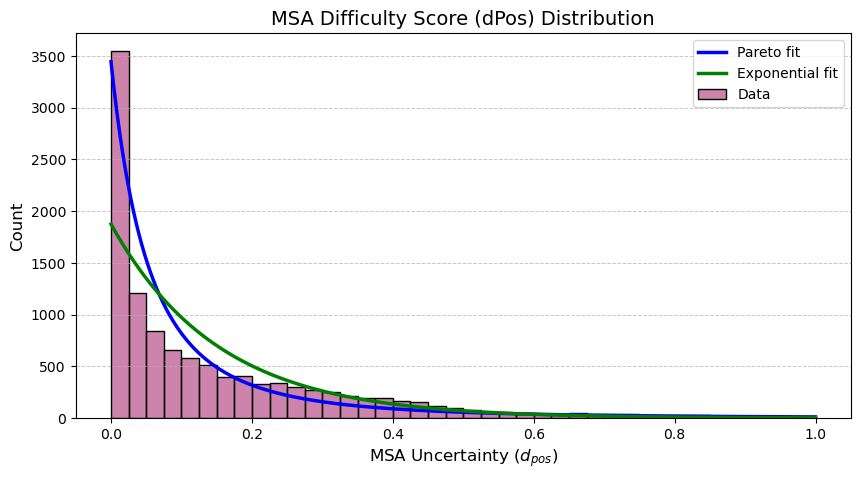

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pareto, expon

# Data
data = labels['dpos']

# Histogram info
counts, bin_edges = np.histogram(data, bins=40)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

plt.figure(figsize=(10, 5))

# Histogram
sns.histplot(data=data, bins=40, color="#AA3377", alpha=0.6, label='Data')

# -------------------
# Pareto fit
# -------------------
pareto_shape, pareto_loc, pareto_scale = pareto.fit(data)
x = np.linspace(data.min(), data.max(), 500)
pareto_pdf = pareto.pdf(x, pareto_shape, loc=pareto_loc, scale=pareto_scale)

# Scale PDF to match histogram counts
pareto_pdf_scaled = pareto_pdf * len(data) * (bin_edges[1] - bin_edges[0])
plt.plot(x, pareto_pdf_scaled, linewidth=2.5, color="blue", label="Pareto fit")

# -------------------
# Exponential fit
# -------------------
exp_loc, exp_scale = expon.fit(data)
exp_pdf = expon.pdf(x, loc=exp_loc, scale=exp_scale)
exp_pdf_scaled = exp_pdf * len(data) * (bin_edges[1] - bin_edges[0])
plt.plot(x, exp_pdf_scaled, linewidth=2.5, color="green", label="Exponential fit")

# -------------------
plt.title('MSA Difficulty Score (dPos) Distribution', size=14)
plt.xlabel(r"MSA Uncertainty ($d_{pos}$)", size=12)
plt.ylabel('Count', size=12)
plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.legend()

plt.show()


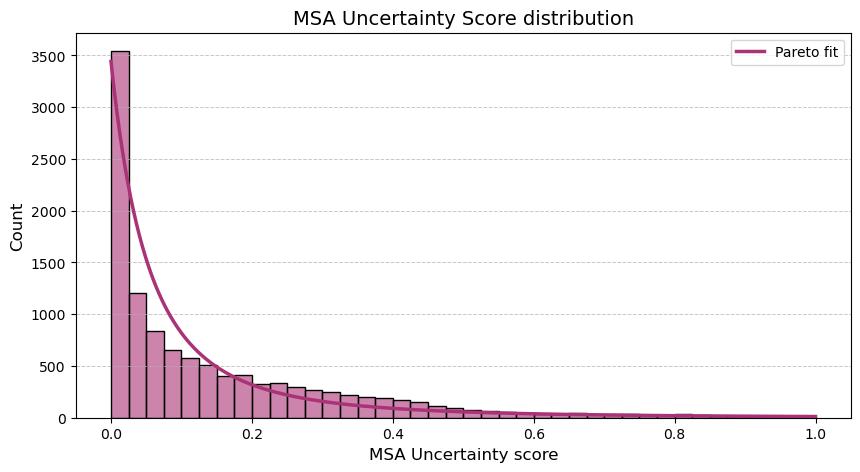

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pareto, expon

# Data
data = labels['dpos']

# Histogram info
counts, bin_edges = np.histogram(data, bins=40)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

plt.figure(figsize=(10, 5))

# Histogram
sns.histplot(data=data, bins=40, color="#AA3377", alpha=0.6)

# -------------------
# Pareto fit
# -------------------
pareto_shape, pareto_loc, pareto_scale = pareto.fit(data)
x = np.linspace(data.min(), data.max(), 500)
pareto_pdf = pareto.pdf(x, pareto_shape, loc=pareto_loc, scale=pareto_scale)

# Scale PDF to match histogram counts
pareto_pdf_scaled = pareto_pdf * len(data) * (bin_edges[1] - bin_edges[0])
plt.plot(x, pareto_pdf_scaled, linewidth=2.5, color="#AA3377", label="Pareto fit")


# -------------------
plt.title('MSA Uncertainty Score distribution', size=14)
plt.xlabel(r"MSA Uncertainty score", size=12)
plt.ylabel('Count', size=12)
plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.legend()

plt.show()


## Performance report study

['0.0423', LGBMRegressor(colsample_bytree=0.38543113775493054,
              feature_fraction_bynode=0.1347175489073508,
              importance_type='gain', learning_rate=0.04550596638376499,
              metric='rmse', min_child_samples=21, n_estimators=1200, n_jobs=-1,
              num_leaves=44, objective='regression', random_state=0,
              reg_alpha=0.025927078827840913, reg_lambda=0.008075641017151906,
              subsample=0.8151632573766253, verbosity=-1), array([   16,    18,    33, ..., 11412, 11416, 11426])]
[   10    22    30 ... 11420 11428 11429]
R² on best fold: 0.957


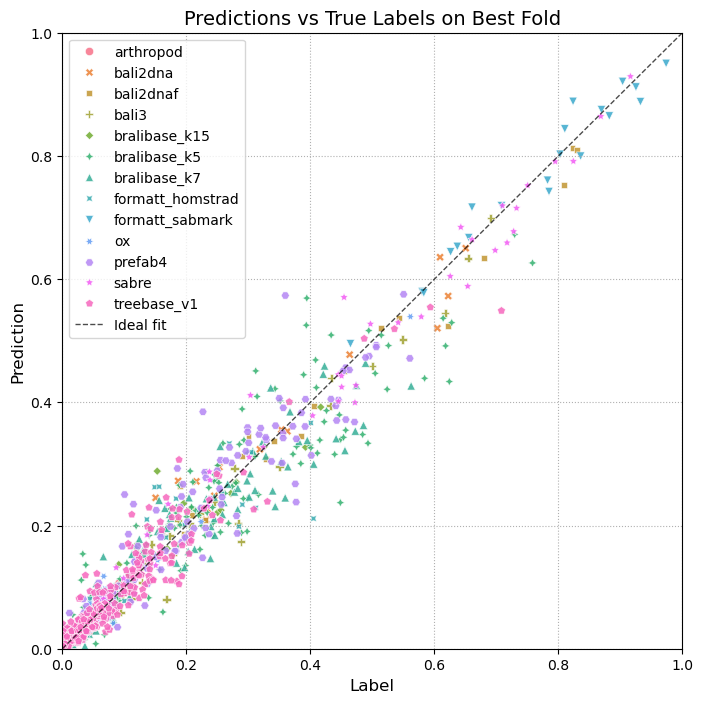

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pickle
import lightgbm as lgb
from lightgbm import LGBMRegressor

splits_params_file = "/hits/fast/cme/luciamf/msa_difficulty/alignment-project/aldiscore/logs/reporting_lucia/splits_params_912554.pkl"

# Load the file
with open(splits_params_file, "rb") as f:
    splits_params = pickle.load(f)

print(splits_params[0])    
    
splits_params_sorted = sorted(splits_params, key=lambda x: x[0])
best_rmse, model, test_idxs = splits_params_sorted[0]

model._n_classes = 1


# final_model_file ="/hits/fast/cme/luciamf/msa_difficulty/alignment-project/aldiscore/aldiscore/models/v1.0_finallucia.txt"

# model = lgb.Booster(model_file=final_model_file)

# model = LGBMRegressor()
# model._Booster = lgb.Booster(model_file=final_model_file)
# model._n_features_in_ = model._Booster.num_features()
# model._n_classes = 1




print(test_idxs)
y_pred = model.predict(feat_df.iloc[test_idxs])
y_true = labels.iloc[test_idxs].to_numpy().ravel()

sources = feat_df.iloc[test_idxs].reset_index().loc[:, "source"]

is_dna = drop_df.iloc[test_idxs].reset_index().loc[:, "is_dna"]

plt.figure(figsize=(8, 8))
sn.scatterplot(
    y=model.predict(feat_df.iloc[test_idxs]),
    x=labels.iloc[test_idxs].to_numpy().ravel(),
    alpha=0.85,
    style=sources,
    hue=sources,
)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, alpha=0.7, label="Ideal fit")   # diagonal line
plt.legend()
plt.ylabel("Prediction", size=12)
plt.xlabel("Label", size=12)
plt.title("Predictions vs True Labels on Best Fold", size=14)
# plt.xticks(np.linspace(0, 1, 5, endpoint=True))
# plt.yticks(np.linspace(0, 1, 5, endpoint=True))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(linestyle=":")

r2 = r2_score(y_true, y_pred)
print(f"R² on best fold: {r2:.3f}")

# sn.scatterplot(
#     x=y_pred,
#     y=y_true,
#     alpha=0.5,
#     hue=is_dna
# )

R² on best fold: 0.957


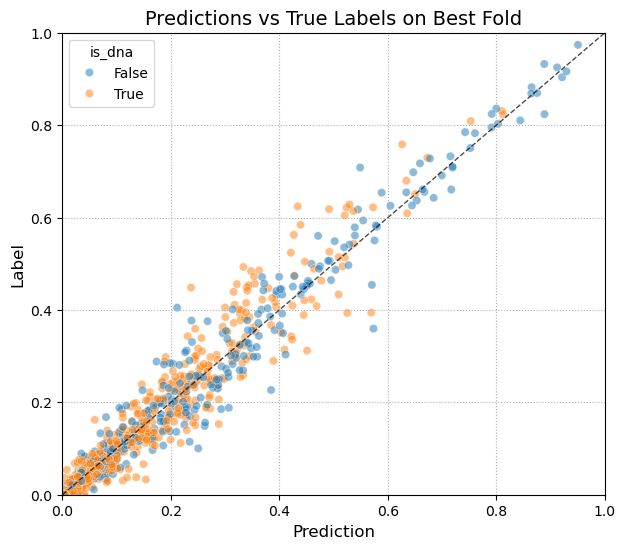

In [ ]:
plt.figure(figsize=(7, 6))

# sn.scatterplot(
#     x=model.predict(feat_df.iloc[test_idxs]),
#     y=labels.iloc[test_idxs].to_numpy().ravel(),
#     alpha=0.85,
#     style=sources,
#     hue=sources,
# )

sn.scatterplot(
    x=y_pred,
    y=y_true,
    alpha=0.5,
    hue=is_dna
)

plt.xlabel("Prediction", size=12)
plt.ylabel("Label", size=12)
plt.title("Predictions vs True Labels on Best Fold", size=14)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, alpha=0.7)   # diagonal line


# plt.xticks(np.linspace(0, 1, 5, endpoint=True))
# plt.yticks(np.linspace(0, 1, 5, endpoint=True))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(linestyle=":")

r2 = r2_score(y_true, y_pred)
print(f"R² on best fold: {r2:.3f}")

